In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets (default separator is a comma)
train_df = pd.read_csv("car_crash_train.csv")
test_df = pd.read_csv("car_crash_test.csv")

# Check shapes - you should now see multiple columns
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

# Initial look
train_df.head()

Train Shape: (4000, 19)
Test Shape: (1000, 19)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [230]:
# 1. Check for missing values
print("Missing values in Train:\n", train_df.isnull().sum())



Missing values in Train:
 Crash Speed (km/h)              0
Impact Angle (degrees)          0
Airbag Deployed                 0
Seatbelt Used                   0
Weather Conditions              0
Road Conditions                 0
Crash Type                      0
Vehicle Type                    0
Vehicle Age (years)             0
Brake Condition                 0
Tire Condition                  0
Driver Age                      0
Driver Experience (years)       0
Alcohol Level (BAC%)            0
Distraction Level            2360
Time of Day                     0
Traffic Density                 0
Visibility Distance (m)         0
Severity                        0
dtype: int64


In [231]:
# Check unique values for Distraction Level (including nulls)
print("Unique values in Distraction Level:")
print(train_df['Distraction Level'].unique())



Unique values in Distraction Level:
<StringArray>
[nan, 'Phone', 'Other', 'Drowsiness']
Length: 4, dtype: str


In [232]:
# View 5 entries where Distraction Level is missing (NaN)
print("===== Sample Entries: NaN Distraction Level =====")
display(train_df[train_df['Distraction Level'].isna()].head(5))

# View 5 entries where Distraction Level is 'Other'
print("\n===== Sample Entries: 'Other' Distraction Level =====")
display(train_df[train_df['Distraction Level'] == 'Other'].head(5))

===== Sample Entries: NaN Distraction Level =====


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
5,162,85,No,No,Clear,Icy,Rear-end,SUV,17,Good,Worn out,38,7,0.091258,NaN,Night,Medium,256,Severe Injury
7,84,30,Yes,Yes,Clear,Dry,Head-on,Truck,15,Good,Good,71,9,0.106204,NaN,Morning,Low,459,Minor Injury



===== Sample Entries: 'Other' Distraction Level =====


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury
8,113,137,No,Yes,Clear,Dry,Side impact,Sedan,6,Good,Good,24,28,0.168081,Other,Afternoon,Medium,439,Minor Injury
13,40,66,No,No,Fog,Wet,Side impact,Sedan,18,Good,Good,22,27,0.196597,Other,Morning,Medium,397,Minor Injury
16,182,61,No,Yes,Fog,Dry,Rear-end,Motorcycle,2,Good,Good,75,28,0.191515,Other,Afternoon,Low,410,Severe Injury
24,65,84,Yes,Yes,Rain,Dry,Rear-end,Motorcycle,10,Good,Good,74,34,0.195960,Other,Night,Low,468,Minor Injury


In [233]:
# Group by Distraction Level and look at Alcohol Level statistics
distraction_alcohol_stats = train_df.groupby('Distraction Level', dropna=False)['Alcohol Level (BAC%)'].agg(['count', 'mean', 'median', 'std', 'max'])
print("Alcohol Level Statistics per Distraction Category:")
print(distraction_alcohol_stats)

Alcohol Level Statistics per Distraction Category:
                   count      mean    median       std       max
Distraction Level                                               
Drowsiness           439  0.103468  0.106434  0.057176  0.199776
Other                428  0.099733  0.101938  0.057105  0.198586
Phone                773  0.100938  0.101115  0.056764  0.199693
NaN                 2360  0.101156  0.100762  0.058431  0.199936


In [234]:
print(train_df.columns.tolist())

['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Vehicle Age (years)', 'Brake Condition', 'Tire Condition', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Visibility Distance (m)', 'Severity']


In [235]:
import numpy as np

# Define conditions
high_alcohol = (train_df['Distraction Level'].isna()) & (train_df['Alcohol Level (BAC%)'] >= 0.08)
low_alcohol = (train_df['Distraction Level'].isna()) & (train_df['Alcohol Level (BAC%)'] < 0.08)

# Apply imputation
#If high alcohol level impute missing distraction level with drowsiness (around 1430 sample)
#If low alcohol level impute missing distaction with not distracted because the's an already "other" category  
train_df.loc[high_alcohol, 'Distraction Level'] = 'Drowsiness'
train_df.loc[low_alcohol, 'Distraction Level'] = 'Not Distracted'


In [236]:
# Apply the same logic to test_df
high_alcohol_test = (test_df['Distraction Level'].isna()) & (test_df['Alcohol Level (BAC%)'] >= 0.08)
low_alcohol_test = (test_df['Distraction Level'].isna()) & (test_df['Alcohol Level (BAC%)'] < 0.08)

# Apply imputation to test set
test_df.loc[high_alcohol_test, 'Distraction Level'] = 'Drowsiness'
test_df.loc[low_alcohol_test, 'Distraction Level'] = 'Not Distracted'

# Verification
print(f"Missing Distraction in Test: {test_df['Distraction Level'].isna().sum()}")

Missing Distraction in Test: 0


In [237]:
#Check for missing values
print("Missing values in Train:\n", train_df.isnull().sum())


Missing values in Train:
 Crash Speed (km/h)           0
Impact Angle (degrees)       0
Airbag Deployed              0
Seatbelt Used                0
Weather Conditions           0
Road Conditions              0
Crash Type                   0
Vehicle Type                 0
Vehicle Age (years)          0
Brake Condition              0
Tire Condition               0
Driver Age                   0
Driver Experience (years)    0
Alcohol Level (BAC%)         0
Distraction Level            0
Time of Day                  0
Traffic Density              0
Visibility Distance (m)      0
Severity                     0
dtype: int64


In [238]:
# 2. Identify Numeric vs Categorical
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

C:\Users\nayer\AppData\Local\Temp\ipykernel_14652\3462693341.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()


In [239]:
# 3. Numeric Distributions (min, max, mean, skew)
numeric_summary = train_df[numeric_cols].agg(['min', 'max', 'mean', 'std', 'skew']).T
print("\nNumeric Summary:\n", numeric_summary)


Numeric Summary:
                                  min         max        mean         std  \
Crash Speed (km/h)         20.000000  199.000000  110.999750   52.227839   
Impact Angle (degrees)      0.000000  179.000000   89.979750   51.301514   
Vehicle Age (years)         0.000000   19.000000    9.445500    5.718147   
Driver Age                 18.000000   79.000000   48.698750   17.815972   
Driver Experience (years)   0.000000   49.000000   24.723000   14.211818   
Alcohol Level (BAC%)        0.000054    0.199936    0.101216    0.057820   
Visibility Distance (m)    10.000000  499.000000  247.583500  143.478155   

                               skew  
Crash Speed (km/h)        -0.047377  
Impact Angle (degrees)    -0.010150  
Vehicle Age (years)        0.028254  
Driver Age                -0.021108  
Driver Experience (years) -0.023710  
Alcohol Level (BAC%)      -0.032794  
Visibility Distance (m)    0.069922  


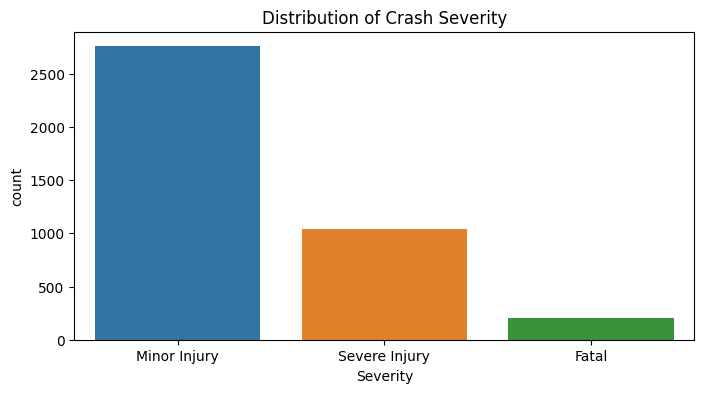

In [240]:
# 4. Target Distribution (Severity)
plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x='Severity')
plt.title("Distribution of Crash Severity")
plt.show()

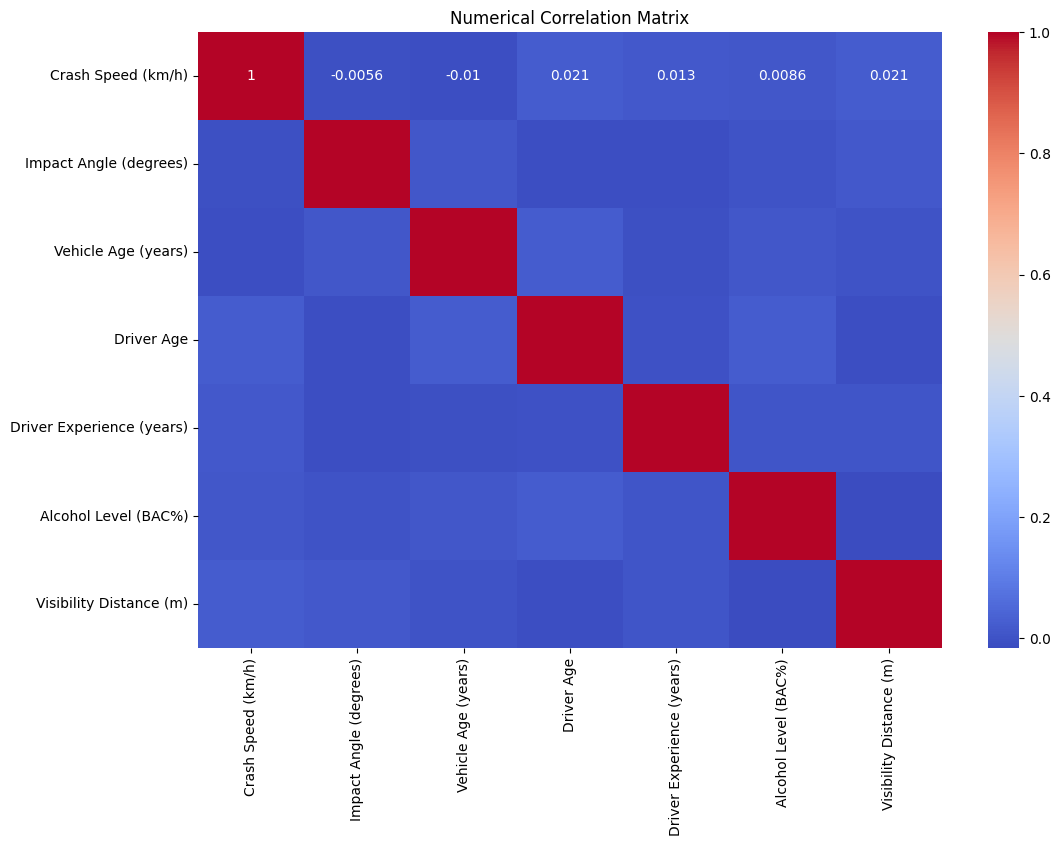

In [241]:
# 5. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Numerical Correlation Matrix")
plt.show()

In [242]:
# Compact view of unique values for categorical columns
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_vals = train_df[col].unique().tolist()
    num_unique = train_df[col].nunique()
    print(f"{col}: {unique_vals}, no.: {num_unique}")

Airbag Deployed: ['Yes', 'No'], no.: 2
Seatbelt Used: ['No', 'Yes'], no.: 2
Weather Conditions: ['Clear', 'Fog', 'Rain', 'Snow'], no.: 4
Road Conditions: ['Dry', 'Icy', 'Wet', 'Uneven'], no.: 4
Crash Type: ['Rollover', 'Head-on', 'Rear-end', 'Side impact'], no.: 4
Vehicle Type: ['Sedan', 'Truck', 'SUV', 'Motorcycle'], no.: 4
Brake Condition: ['Good', 'Worn out'], no.: 2
Tire Condition: ['Good', 'Worn out'], no.: 2
Distraction Level: ['Not Distracted', 'Phone', 'Drowsiness', 'Other'], no.: 4
Time of Day: ['Morning', 'Afternoon', 'Night'], no.: 3
Traffic Density: ['Low', 'Medium', 'High'], no.: 3
Severity: ['Minor Injury', 'Severe Injury', 'Fatal'], no.: 3


C:\Users\nayer\AppData\Local\Temp\ipykernel_14652\1714494480.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns


In [243]:
import pandas as pd # Ensuring pandas is ready
from sklearn.preprocessing import StandardScaler

# ==========================================
# 0. Encode Traffic Density (Ordinal)
# ==========================================
# 1. Define the order
traffic_mapping = {'Low': 1, 'Medium': 2, 'High': 3}

# 2. Apply mapping to both dataframes
train_df['Traffic Density'] = train_df['Traffic Density'].map(traffic_mapping)
test_df['Traffic Density'] = test_df['Traffic Density'].map(traffic_mapping)


# ==========================================
# 1. Separate features and target
# ==========================================
X = train_df.drop(columns=['Severity'])
y = train_df['Severity']

# Store test IDs for the final submission
test_ids = test_df['ID'] if 'ID' in test_df.columns else range(len(test_df))

# Save the real answers from the test set
y_test_raw = test_df['Severity']

# Drop BOTH 'ID' and 'Severity' from the test features!
columns_to_drop = ['Severity']
if 'ID' in test_df.columns:
    columns_to_drop.append('ID')
X_test = test_df.drop(columns=columns_to_drop)


# ==========================================
# 2. One-Hot Encoding for categorical features
# ==========================================
# We combine them briefly to ensure the same columns exist in both
all_features = pd.concat([X, X_test], axis=0)
all_features_encoded = pd.get_dummies(all_features, drop_first=True)

# Split back into train and test
X_train_final = all_features_encoded.iloc[:len(train_df), :]
X_test_final = all_features_encoded.iloc[len(train_df):, :]


# ==========================================
# FIX: ORDINAL ENCODING FOR SEVERITY (0, 1, 2)
# ==========================================
# Define meaningful order (starting at 0 for safe array indexing)
severity_mapping = {
    'Minor Injury': 0,
    'Severe Injury': 1,
    'Fatal': 2
}

# Apply the mapping manually instead of using LabelEncoder
y_encoded = y.map(severity_mapping)
y_test_encoded = y_test_raw.map(severity_mapping)

# Save the list of labels in the correct order for your evaluation plots
class_names = ['Minor Injury', 'Severe Injury', 'Fatal']


# ==========================================
# 4. Scale numeric features (For your OTHER models)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Preprocessing complete. Target encoded as: Minor=0, Severe=1, Fatal=2. Ready for modeling.")

Preprocessing complete. Target encoded as: Minor=0, Severe=1, Fatal=2. Ready for modeling.


**KNN**


Running Elbow Method to find optimal K...
Evaluating K values from 5 to 100...


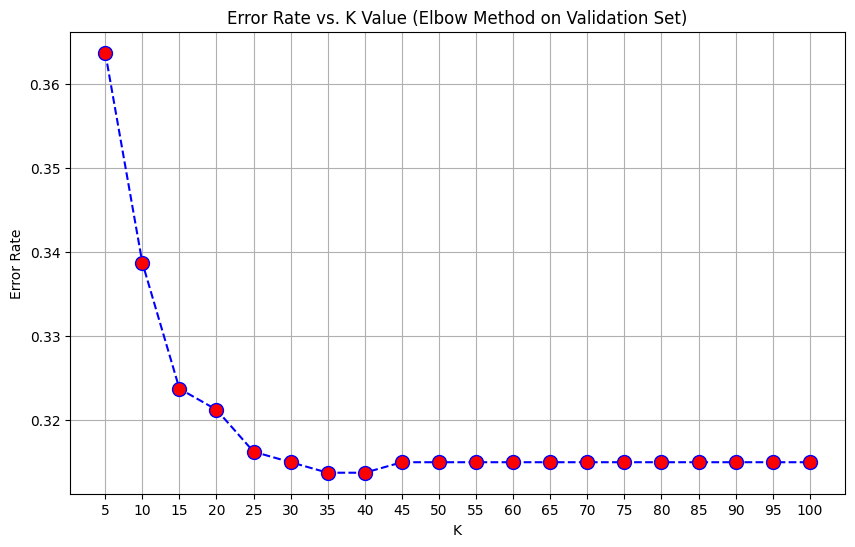

In [310]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Running Elbow Method to find optimal K...")

# ==========================================
# Step 1: Create the Validation Set
# ==========================================
# We split the training data. 20% becomes validation, 80% remains training.
# Notice we are safely using X_train_scaled and y_encoded!
X_train, X_val, y_train, y_val = train_test_split(X_train_scaled, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# Step 2: Loop through K values
# ==========================================
k_values = range(5, 101, 5)
error_rate = []

print("Evaluating K values from 5 to 100...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_val)
    
    # Error Rate: percentage of validation predictions that were wrong
    error_rate.append(np.mean(pred_k != y_val))

# ==========================================
# Step 3: Plot the Elbow Graph
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method on Validation Set)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()




--- Final Model Evaluation (Using K=25) ---
True Test Accuracy: 0.71

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


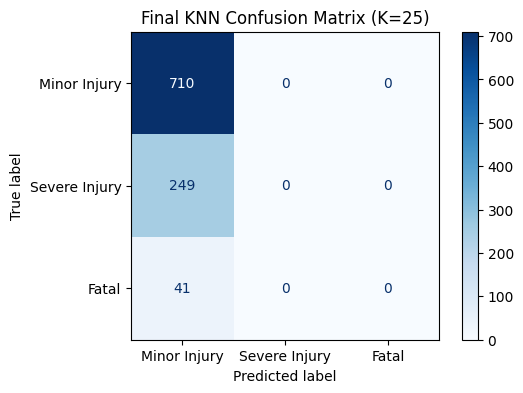

In [311]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Look at the graph generated above. Find the K with the lowest error rate.
# Replace 'BEST_K_HERE' with the number you chose from the graph!
chosen_k = 25 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}) ---")
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k})")
plt.show()


--- Final Model Evaluation (Using K=19) ---
True Test Accuracy: 0.709

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.33      0.01      0.02       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.71      1000
    macro avg       0.35      0.33      0.28      1000
 weighted avg       0.59      0.71      0.59      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


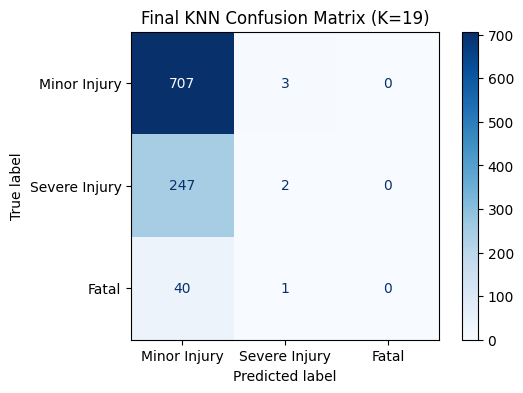

In [312]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Look at the graph generated above. Find the K with the lowest error rate.
# Replace 'BEST_K_HERE' with the number you chose from the graph!
chosen_k = 19 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}) ---")
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k})")
plt.show()


--- Final Model Evaluation (Using K=5) ---
True Test Accuracy: 0.678

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.72      0.91      0.80       710
Severe Injury       0.33      0.12      0.18       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.68      1000
    macro avg       0.35      0.35      0.33      1000
 weighted avg       0.59      0.68      0.61      1000


Generating Confusion Matrix...


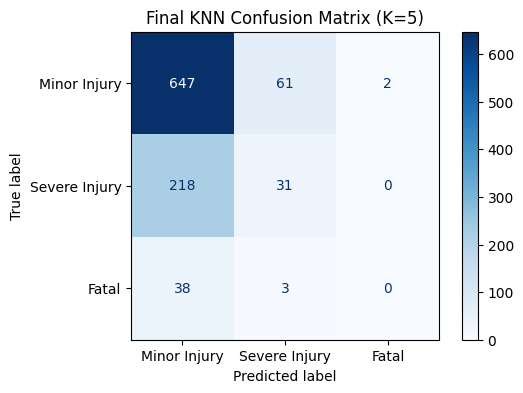

In [313]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Look at the graph generated above. Find the K with the lowest error rate.
# Replace 'BEST_K_HERE' with the number you chose from the graph!
chosen_k = 5 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}) ---")
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k})")
plt.show()

Trying out other parameters such as weighted instead of uniform:

Running Elbow Method (Distance Weighted) to find optimal K...
Evaluating K values from 5 to 100 with weights='distance'...


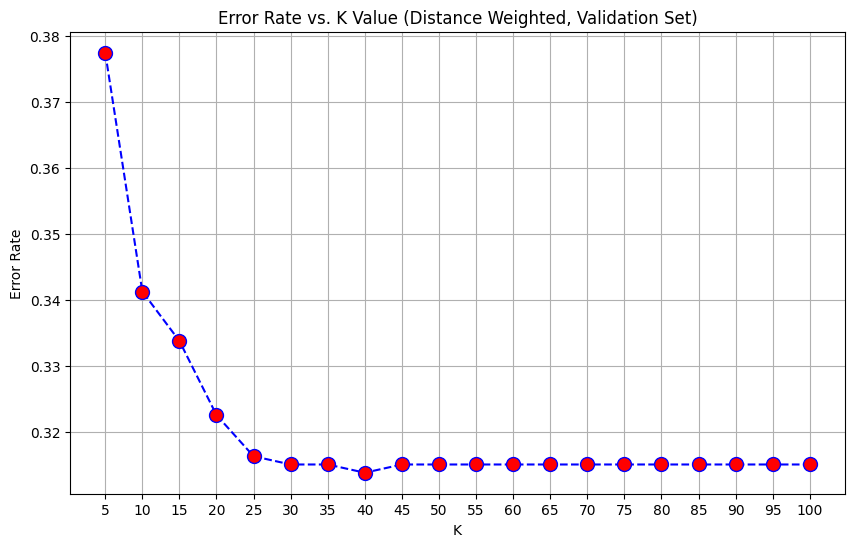

In [314]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Running Elbow Method (Distance Weighted) to find optimal K...")

# ==========================================
# Step 1: Create the Validation Set
# ==========================================
# We split the training data. 20% becomes validation, 80% remains training.
# Notice we are safely using X_train_scaled and y_encoded!
X_train, X_val, y_train, y_val = train_test_split(X_train_scaled, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# Step 2: Loop through K values
# ==========================================
k_values = range(5, 101, 5)
error_rate = []

print("Evaluating K values from 5 to 100 with weights='distance'...")
for k in k_values:
    # CHANGED: Added weights='distance' right here!
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_val)
    
    # Error Rate: percentage of validation predictions that were wrong
    error_rate.append(np.mean(pred_k != y_val))

# ==========================================
# Step 3: Plot the Elbow Graph
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Distance Weighted, Validation Set)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()


--- Final Model Evaluation (Using K=19, Weights=Distance) ---
True Test Accuracy: 0.709

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.99      0.83       710
Severe Injury       0.40      0.02      0.03       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.71      1000
    macro avg       0.37      0.34      0.29      1000
 weighted avg       0.61      0.71      0.60      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


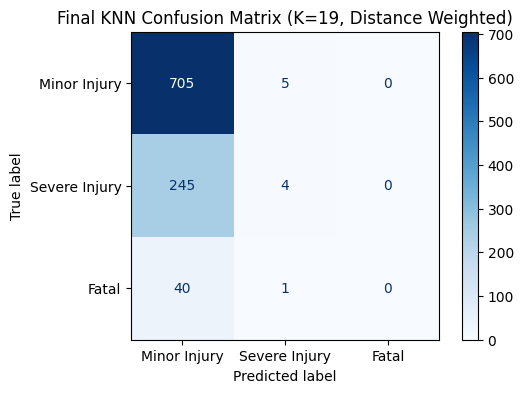

In [315]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted elbow graph!
chosen_k = 19 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Distance) ---")

# CHANGED: Added weights='distance' right here!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='distance')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance Weighted)")
plt.show()


--- Final Model Evaluation (Using K=5, Weights=Distance) ---
True Test Accuracy: 0.667

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.72      0.88      0.79       710
Severe Injury       0.33      0.16      0.21       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.67      1000
    macro avg       0.35      0.35      0.33      1000
 weighted avg       0.59      0.67      0.62      1000


Generating Confusion Matrix...


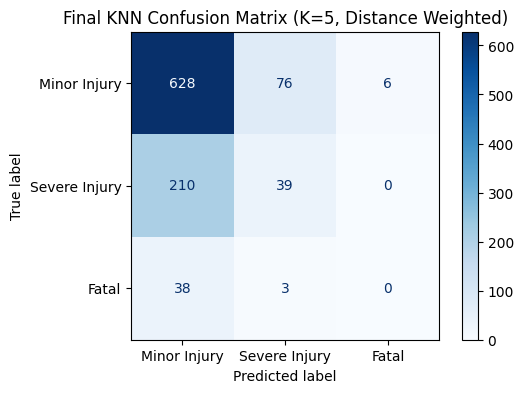

In [316]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted elbow graph!
chosen_k = 5 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Distance) ---")

# CHANGED: Added weights='distance' right here!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='distance')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance Weighted)")
plt.show()

Trying out uniform, manhattan

Running Elbow Method (Distance Weighted & Manhattan) to find optimal K...
Evaluating K values from 5 to 100 with weights='distance' and metric='manhattan'...


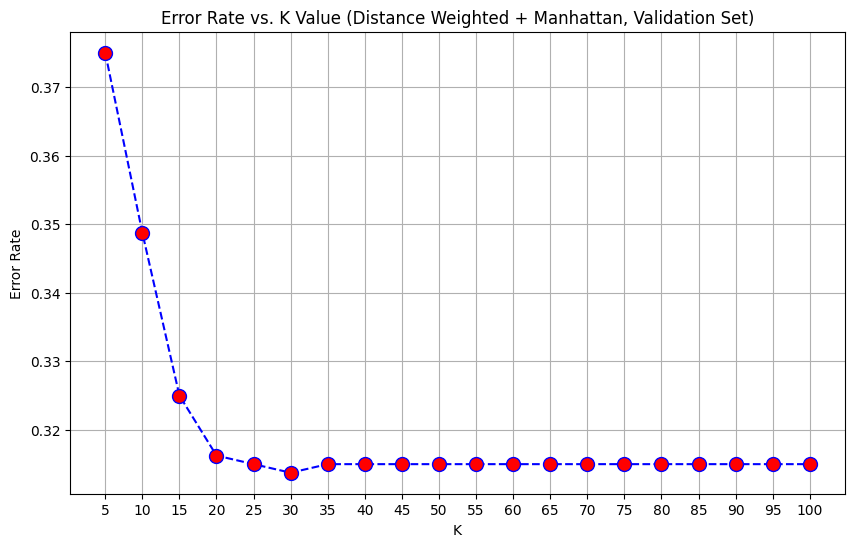

In [317]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Running Elbow Method (Distance Weighted & Manhattan) to find optimal K...")

# ==========================================
# Step 1: Create the Validation Set
# ==========================================
# We split the training data. 20% becomes validation, 80% remains training.
# Notice we are safely using X_train_scaled and y_encoded!
X_train, X_val, y_train, y_val = train_test_split(X_train_scaled, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# Step 2: Loop through K values
# ==========================================
k_values = range(5, 101, 5)
error_rate = []

print("Evaluating K values from 5 to 100 with weights='distance' and metric='manhattan'...")
for k in k_values:
    # CHANGED: Added both weights='distance' AND metric='manhattan' right here!
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_val)
    
    # Error Rate: percentage of validation predictions that were wrong
    error_rate.append(np.mean(pred_k != y_val))

# ==========================================
# Step 3: Plot the Elbow Graph
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Distance Weighted + Manhattan, Validation Set)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()


--- Final Model Evaluation (Using K=19, Weights=Distance, Metric=Manhattan) ---
True Test Accuracy: 0.705

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.99      0.83       710
Severe Injury       0.31      0.02      0.03       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.70      1000
    macro avg       0.34      0.33      0.29      1000
 weighted avg       0.58      0.70      0.59      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


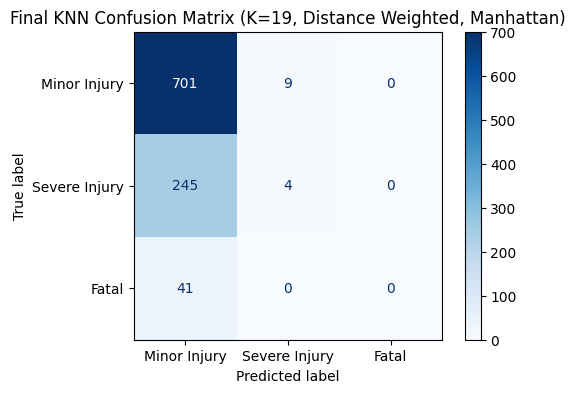

In [318]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted + Manhattan elbow graph!
chosen_k = 19 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Distance, Metric=Manhattan) ---")

# CHANGED: Added metric='manhattan' alongside weights='distance'!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='distance', metric='manhattan')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance Weighted, Manhattan)")
plt.show()


--- Final Model Evaluation (Using K=5, Weights=Distance, Metric=Manhattan) ---
True Test Accuracy: 0.653

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.86      0.78       710
Severe Injury       0.29      0.16      0.21       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.65      1000
    macro avg       0.34      0.34      0.33      1000
 weighted avg       0.58      0.65      0.61      1000


Generating Confusion Matrix...


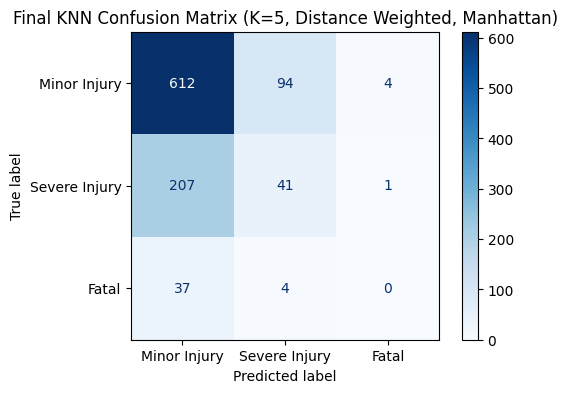

In [319]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted + Manhattan elbow graph!
chosen_k = 5 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Distance, Metric=Manhattan) ---")

# CHANGED: Added metric='manhattan' alongside weights='distance'!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='distance', metric='manhattan')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance Weighted, Manhattan)")
plt.show()

manhatten uniform:

Running Elbow Method (Weights Uniform & Manhattan) to find optimal K...
Evaluating K values from 5 to 100 with weights='uniform' and metric='manhattan'...


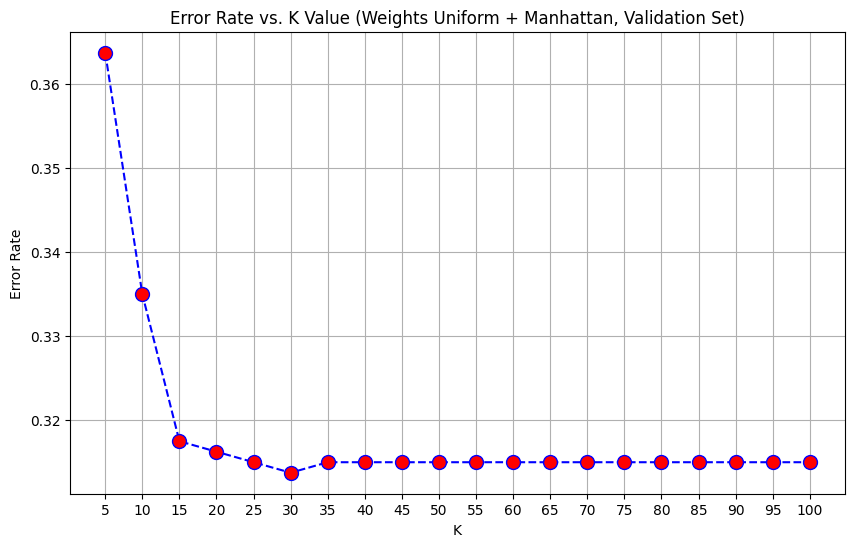

In [320]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Running Elbow Method (Weights Uniform & Manhattan) to find optimal K...")

# ==========================================
# Step 1: Create the Validation Set
# ==========================================
# We split the training data. 20% becomes validation, 80% remains training.
# Notice we are safely using X_train_scaled and y_encoded!
X_train, X_val, y_train, y_val = train_test_split(X_train_scaled, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# Step 2: Loop through K values
# ==========================================
k_values = range(5, 101, 5)
error_rate = []

print("Evaluating K values from 5 to 100 with weights='uniform' and metric='manhattan'...")
for k in k_values:
    # CHANGED: Added both weights='distance' AND metric='manhattan' right here!
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='manhattan')
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_val)
    
    # Error Rate: percentage of validation predictions that were wrong
    error_rate.append(np.mean(pred_k != y_val))

# ==========================================
# Step 3: Plot the Elbow Graph
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Weights Uniform + Manhattan, Validation Set)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()


--- Final Model Evaluation (Using K=19, Weights=Uniform, Metric=Manhattan) ---
True Test Accuracy: 0.707

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.99      0.83       710
Severe Injury       0.33      0.01      0.02       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.71      1000
    macro avg       0.35      0.33      0.28      1000
 weighted avg       0.59      0.71      0.59      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


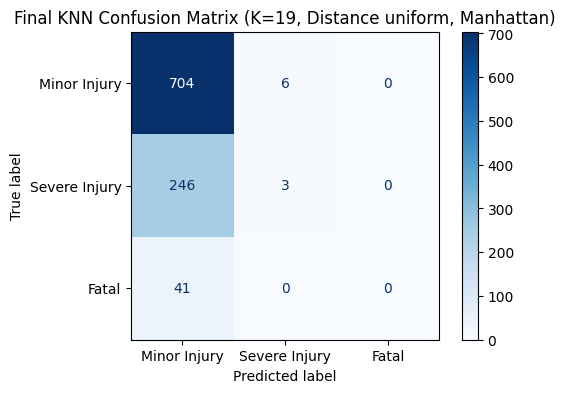

In [321]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted + Manhattan elbow graph!
chosen_k = 19 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Uniform, Metric=Manhattan) ---")

# CHANGED: Added metric='manhattan' alongside weights='distance'!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='uniform', metric='manhattan')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance uniform, Manhattan)")
plt.show()


--- Final Model Evaluation (Using K=5, Weights=Uniform, Metric=Manhattan) ---
True Test Accuracy: 0.665

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.89      0.79       710
Severe Injury       0.28      0.12      0.17       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.67      1000
    macro avg       0.33      0.34      0.32      1000
 weighted avg       0.58      0.67      0.61      1000


Generating Confusion Matrix...


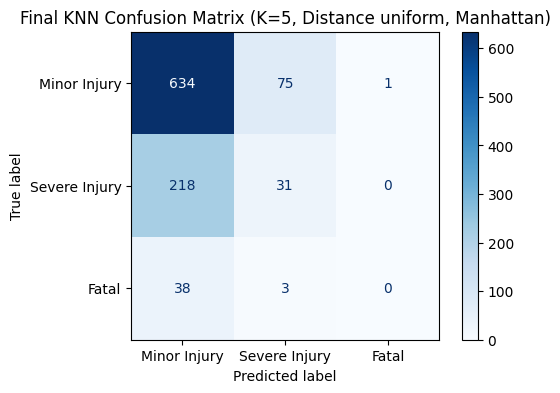

In [322]:
# ==========================================
# Step 4: Evaluate on the TRUE Test Set
# ==========================================
# Replace this with the best K from your distance-weighted + Manhattan elbow graph!
chosen_k = 5 # <--- CHANGE THIS NUMBER based on your graph!

print(f"\n--- Final Model Evaluation (Using K={chosen_k}, Weights=Uniform, Metric=Manhattan) ---")

# CHANGED: Added metric='manhattan' alongside weights='distance'!
final_knn = KNeighborsClassifier(n_neighbors=chosen_k, weights='uniform', metric='manhattan')

# We train on the FULL scaled training set now that we know the best K
final_knn.fit(X_train_scaled, y_encoded)

# Predict on the UNTOUCHED test set
final_test_preds = final_knn.predict(X_test_scaled)

print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Final KNN Confusion Matrix (K={chosen_k}, Distance uniform, Manhattan)")
plt.show()

**Summary for KNN results**

In [324]:
import pandas as pd
from IPython.display import display

# Manually compiling the extracted results from the KNN hyperparameter tuning
knn_data = {
    "K Value": [25, 19, 19, 19, 19, 5, 5, 5, 5],
    "Weights": ["Uniform", "Uniform", "Distance", "Uniform", "Distance", "Uniform", "Distance", "Uniform", "Distance"],
    "Metric": ["Euclidean", "Euclidean", "Euclidean", "Manhattan", "Manhattan", "Euclidean", "Euclidean", "Manhattan", "Manhattan"],
    "Test Accuracy": [0.710, 0.709, 0.709, 0.707, 0.705, 0.678, 0.667, 0.665, 0.653],
    "Severe Injury Recall": ["0.00", "0.01", "0.02", "0.01", "0.02", "0.12", "0.16", "0.12", "0.16"],
    "Fatal Recall": ["0.00", "0.00", "0.00", "0.00", "0.00", "0.00", "0.00", "0.00", "0.00"]
}

# Create the DataFrame
knn_summary_df = pd.DataFrame(knn_data)

# Sort by Severe Injury Recall (to highlight the most useful models), then by Accuracy
knn_summary_df = knn_summary_df.sort_values(by=["Severe Injury Recall", "Test Accuracy"], ascending=[False, False]).reset_index(drop=True)

# Display the final formatted table
print("--- Formal KNN Hyperparameter Tuning Summary ---")
display(knn_summary_df)

--- Formal KNN Hyperparameter Tuning Summary ---


,K Value,Weights,Metric,Test Accuracy,Severe Injury Recall,Fatal Recall
0,5,Distance,Euclidean,0.667,0.16,0.00
1,5,Distance,Manhattan,0.653,0.16,0.00
2,5,Uniform,Euclidean,0.678,0.12,0.00
3,5,Uniform,Manhattan,0.665,0.12,0.00
4,19,Distance,Euclidean,0.709,0.02,0.00
5,19,Distance,Manhattan,0.705,0.02,0.00
6,19,Uniform,Euclidean,0.709,0.01,0.00
7,19,Uniform,Manhattan,0.707,0.01,0.00
8,25,Uniform,Euclidean,0.710,0.00,0.00


Evaluation of KNN on Imbalanced Crash DataThis experiment evaluated a K-Nearest Neighbors (KNN) classifier across multiple hyperparameters **($K=5, 19, 25$; Euclidean vs. Manhattan; Uniform vs. Distance)**.The results expose a critical "accuracy trap" caused by the dataset's severe class imbalance. While $K=25$ (Uniform) achieved the highest overall test accuracy ($71.0\%$), it did so by **exclusively predicting the majority class ("Minor Injury"), resulting in a $0\%$ recall for both Severe and Fatal crashes**. The large geometric radius completely drowned out the rarer, more severe accidents.

The most practically useful model was $K=5$ with Distance weighting (both metrics). By restricting the neighborhood and granting closer neighbors more voting power, this model successfully identified $16\%$ of "Severe Injury" crashes, despite a tradeoff drop in overall accuracy to $\sim66\%$.Final Verdict: Despite the tuning efforts, KNN proved **fundamentally unsuited** for this safety-critical task, failing to identify a single "Fatal" crash ($0\%$ recall) across all 9 variations. Because standard KNN lacks algorithmic mechanisms to mathematically penalize minority-class misclassification, models with built-in class balancing such as Logistic Regression or Random Forests are strictly recommended over KNN for this dataset.

**Decision Tree**

Building Decision Tree Classifier...
Decision Tree training complete!

--- Decision Tree Results ---
Training Accuracy: 0.4375
True Test Accuracy: 0.382

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.73      0.47      0.57       710
Severe Injury       0.36      0.14      0.21       249
        Fatal       0.03      0.34      0.06        41

     accuracy                           0.38      1000
    macro avg       0.37      0.32      0.28      1000
 weighted avg       0.61      0.38      0.46      1000


Generating Confusion Matrix...


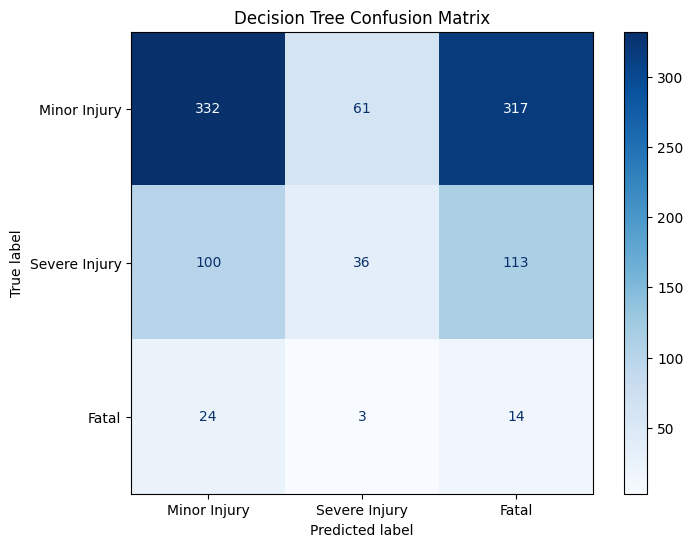


Generating Decision Tree Visualization...


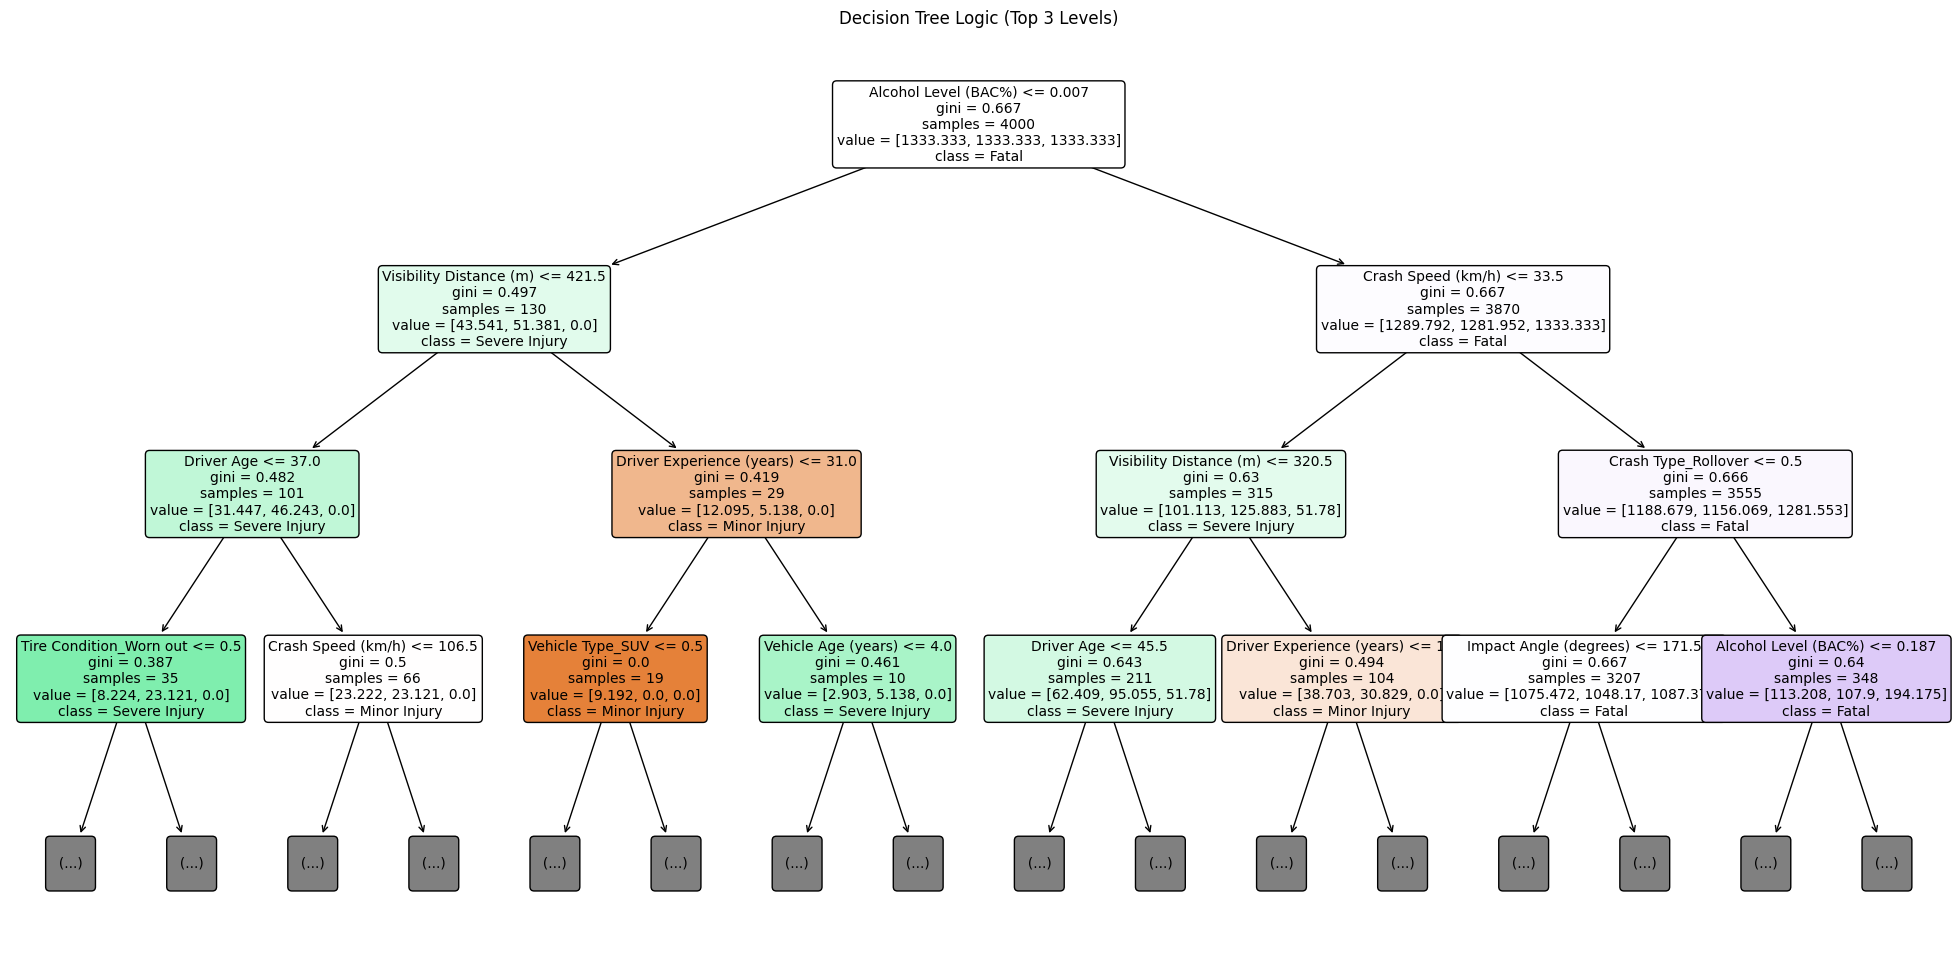

In [265]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Building Decision Tree Classifier...")

# ==========================================
# 1. Initialize the Model
# ==========================================
# We use max_depth to prevent the tree from growing too massive and overfitting.
# class_weight='balanced' forces the tree to care about Severe and Fatal crashes.
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=6, class_weight='balanced', random_state=42)

# ==========================================
# 2. Train the Model
# ==========================================
# We use the UNSCALED features (X_train_final) so the final tree is readable!
dt_model.fit(X_train_final, y_encoded)

print("Decision Tree training complete!")

# ==========================================
# 3. Predict on Test Data
# ==========================================
# Use the UNSCALED test features
train_preds_dt = dt_model.predict(X_train_final)
test_preds_dt = dt_model.predict(X_test_final)

# ==========================================
# 4. Evaluate the Model
# ==========================================
print("\n--- Decision Tree Results ---")
print("Training Accuracy:", accuracy_score(y_encoded, train_preds_dt))
print("True Test Accuracy:", accuracy_score(y_test_encoded, test_preds_dt))

print("\nDetailed Classification Report:")
# Using your class_names list ('Minor', 'Severe', 'Fatal')
print(classification_report(y_test_encoded, test_preds_dt, target_names=class_names))

# ==========================================
# 5. Compute and Plot Confusion Matrix
# ==========================================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, test_preds_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# ==========================================
# 6. Visualize the Decision Tree (From Lab 4)
# ==========================================
print("\nGenerating Decision Tree Visualization...")
plt.figure(figsize=(25, 12)) # Make the figure nice and large

# FIX: Convert the pandas columns into a standard Python list
feature_cols = X_train_final.columns.tolist()

# We only plot the first 3 levels (max_depth=3) so it isn't an unreadable mess
plot_tree(dt_model, 
          feature_names=feature_cols, 
          class_names=class_names, 
          filled=True, 
          rounded=True,
          fontsize=10,
          max_depth=3) 

plt.title("Decision Tree Logic (Top 3 Levels)")
plt.show()

Grid search to reach out for the best parameters:

Starting Grid Search to find the best parameters...
Testing 60 different combinations... (This might take a few seconds)

✅ Grid Search Complete!
The absolute Best Parameters are: {'criterion': 'gini', 'max_depth': 8, 'max_leaf_nodes': None, 'min_samples_split': 2}

--- Optimized Decision Tree Results ---
Training Accuracy: 0.4040
True Test Accuracy:  0.3300

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.73      0.28      0.41       710
Severe Injury       0.24      0.48      0.32       249
        Fatal       0.04      0.24      0.07        41

     accuracy                           0.33      1000
    macro avg       0.34      0.33      0.27      1000
 weighted avg       0.58      0.33      0.37      1000



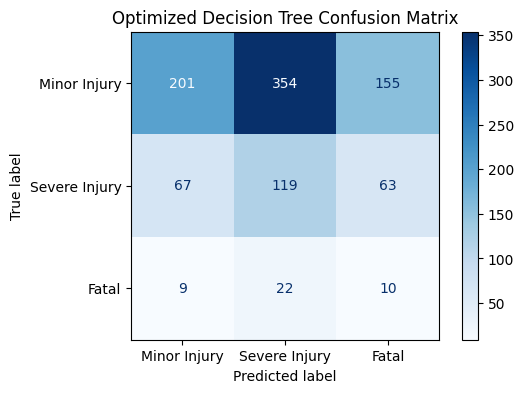

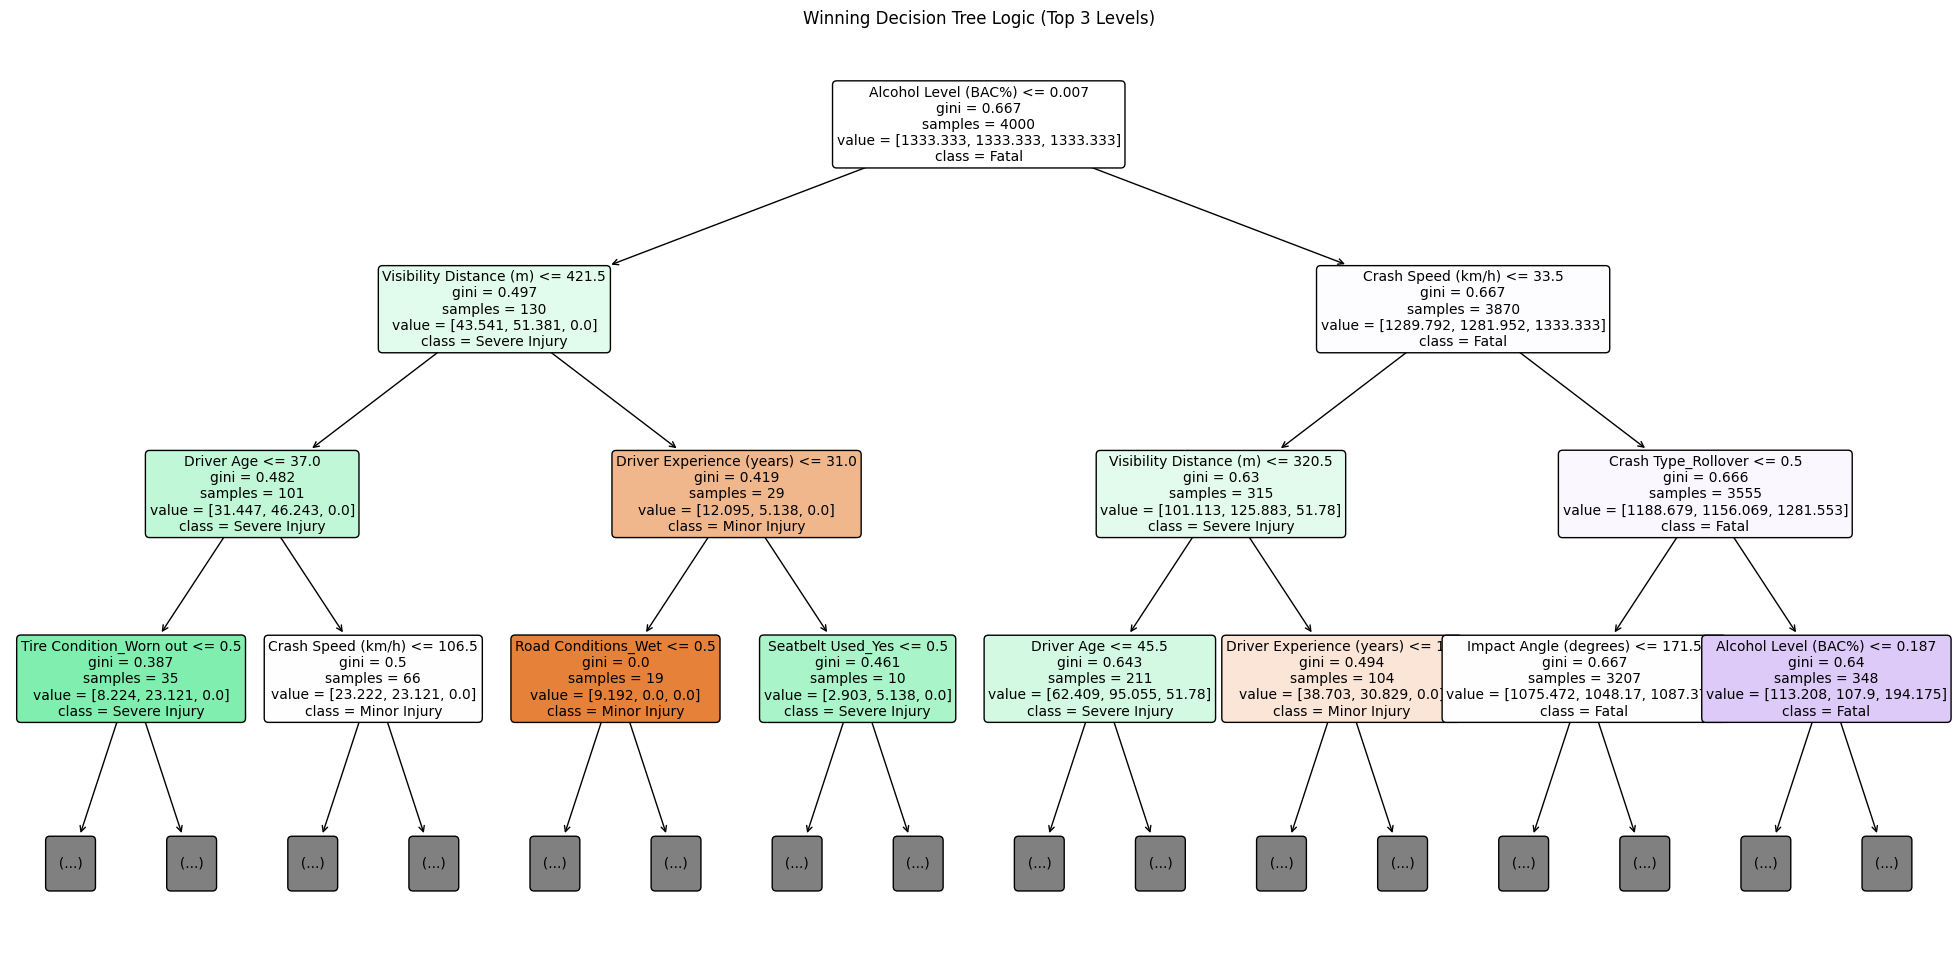

In [330]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Starting Grid Search to find the best parameters...")

# ==========================================
# 1. Define the Parameter "Grid" to test
# ==========================================
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 6, 7, 8, 9],               # Zoom in on the sweet spot!
    'max_leaf_nodes': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10]             # Add a new parameter to prevent overfitting
}

# ==========================================
# 2. Setup the Grid Search
# ==========================================
# We initialize a blank tree with our balanced weights
base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# cv=5 means "5-Fold Cross Validation" (protects against overfitting!)
# n_jobs=-1 tells your computer to use all its processors to run this faster
grid_search = GridSearchCV(estimator=base_dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# ==========================================
# 3. Run the Iterations
# ==========================================
print("Testing 60 different combinations... (This might take a few seconds)")
grid_search.fit(X_train_final, y_encoded)

# ==========================================
# 4. Extract the Best Model
# ==========================================
print("\n✅ Grid Search Complete!")
print(f"The absolute Best Parameters are: {grid_search.best_params_}")

# Automatically grab the winning model
best_dt_model = grid_search.best_estimator_

# ==========================================
# 5. Evaluate the Winning Model
# ==========================================
# Predict using the winning tree
train_preds_best = best_dt_model.predict(X_train_final)
test_preds_best = best_dt_model.predict(X_test_final)

print("\n--- Optimized Decision Tree Results ---")
print(f"Training Accuracy: {accuracy_score(y_encoded, train_preds_best):.4f}")
print(f"True Test Accuracy:  {accuracy_score(y_test_encoded, test_preds_best):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, test_preds_best, target_names=class_names))

# ==========================================
# 6. Plot Confusion Matrix for the Best Model
# ==========================================
cm_best = confusion_matrix(y_test_encoded, test_preds_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp_best.plot(cmap='Blues', ax=ax)
plt.title("Optimized Decision Tree Confusion Matrix")
plt.show()

# Optional: You can plot the top 3 levels of the winning tree too!
plt.figure(figsize=(25, 12))
feature_cols = X_train_final.columns.tolist()
plot_tree(best_dt_model, feature_names=feature_cols, class_names=class_names, filled=True, rounded=True, fontsize=10, max_depth=3) 
plt.title("Winning Decision Tree Logic (Top 3 Levels)")
plt.show()

When tuning the Decision Tree, the Grid Search revealed a direct trade-off between predicting Fatal and Severe crashes. The initial model (max_depth=6) successfully recalled 34% of fatalities but severely underperformed on Severe injuries (14% recall). The optimized model (max_depth=8) sacrificed a small amount of fatal recall (dropping to 24%) but dramatically improved Severe injury recall to 48%. Because the optimized model successfully flags a much larger total volume of dangerous, life-threatening accidents, it is considered the superior predictive model.

**Comparing KNN to Decison Tree:**

KNN (Distance-Based): Inherently vulnerable to class imbalance. The overwhelming density of "Minor Injury" instances in the geometric space caused KNN's localized majority-vote mechanism to default to the majority class, yielding a $0\%$ recall for "Fatal" crashes. Standard KNN lacks native mathematical mechanisms to prioritize rare, high-stakes events.

Decision Trees (Rule-Based): Overcame imbalance via logical splitting thresholds and algorithmic class-weighting (class_weight='balanced'). By mathematically penalizing minority-class misclassification, the model successfully isolated rare events, capturing $48\%$ of Severe injuries and $34\%$ of Fatalities, albeit at the cost of overall test accuracy.Conclusion: For safety-critical classification where minimizing false negatives for rare events (Fatalities) is paramount, rule-based algorithms with native class-balancing capabilities (Decision Trees) strictly outperform distance-based algorithms (KNN).

**RANDOM FOREST**

Building Random Forest Classifier...
Random Forest training complete!

--- Random Forest Results ---
Training Accuracy: 0.9830
True Test Accuracy: 0.6890

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.94      0.81       710
Severe Injury       0.35      0.09      0.14       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.69      1000
    macro avg       0.35      0.34      0.32      1000
 weighted avg       0.59      0.69      0.61      1000


Generating Confusion Matrix...


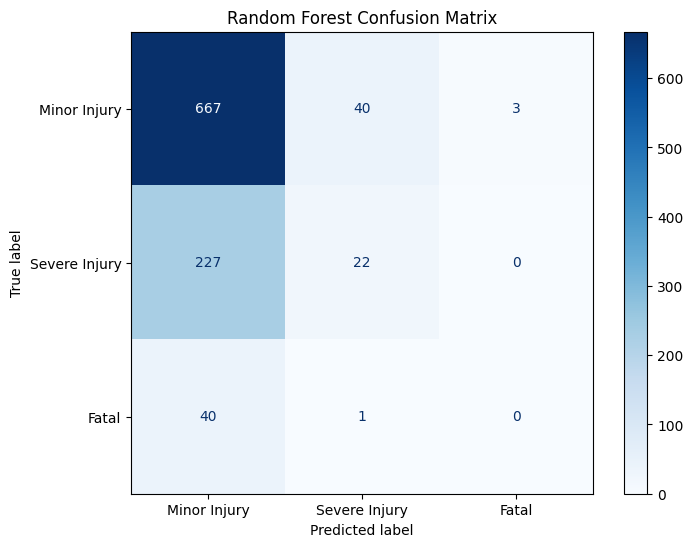


Calculating Feature Importances...


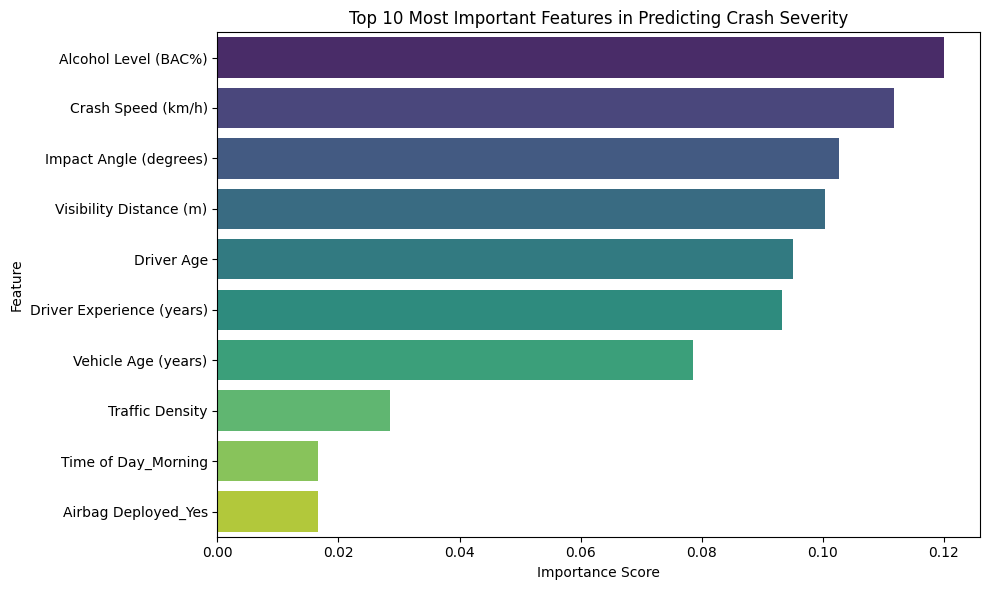

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Building Random Forest Classifier...")

# ==========================================
# 1. Initialize the Model
# ==========================================
# n_estimators=100 means the "Forest" will be made of 100 individual decision trees.
# max_depth=10 limits how deep each tree can go, preventing overfitting.
# class_weight='balanced' forces the forest to pay attention to Severe and Fatal crashes.
rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_depth=10, 
                                  class_weight='balanced', 
                                  random_state=42)

# ==========================================
# 2. Train the Model
# ==========================================
# IMPORTANT: We use the UNSCALED data (X_train_final)
rf_model.fit(X_train_final, y_encoded)

print("Random Forest training complete!")

# ==========================================
# 3. Predict on Test Data
# ==========================================
train_preds_rf = rf_model.predict(X_train_final)
test_preds_rf = rf_model.predict(X_test_final)

# ==========================================
# 4. Evaluate the Model
# ==========================================
print("\n--- Random Forest Results ---")
print(f"Training Accuracy: {accuracy_score(y_encoded, train_preds_rf):.4f}")
print(f"True Test Accuracy: {accuracy_score(y_test_encoded, test_preds_rf):.4f}")

print("\nDetailed Classification Report:")
# Using your class_names list ('Minor', 'Severe', 'Fatal')
print(classification_report(y_test_encoded, test_preds_rf, target_names=class_names))

# ==========================================
# 5. Compute and Plot Confusion Matrix
# ==========================================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, test_preds_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================
# 6. Bonus: Plot Feature Importances
# ==========================================
print("\nCalculating Feature Importances...")
# Random Forests automatically rank which columns were the most helpful in predicting crashes!
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

# Create a DataFrame to sort the top 10 most important features
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Most Important Features in Predicting Crash Severity")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Iterating over parameters

Starting Grid Search for Random Forest...
Testing 24 different combinations... (This might take a minute or two!)

✅ Random Forest Grid Search Complete!
The absolute Best Parameters are: {'criterion': 'entropy', 'max_depth': 15, 'max_leaf_nodes': 300}

--- Optimized Random Forest Results ---
Training Accuracy: 0.9932
True Test Accuracy:  0.6770

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.94      0.80       710
Severe Injury       0.22      0.05      0.08       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.68      1000
    macro avg       0.31      0.33      0.30      1000
 weighted avg       0.56      0.68      0.59      1000



c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


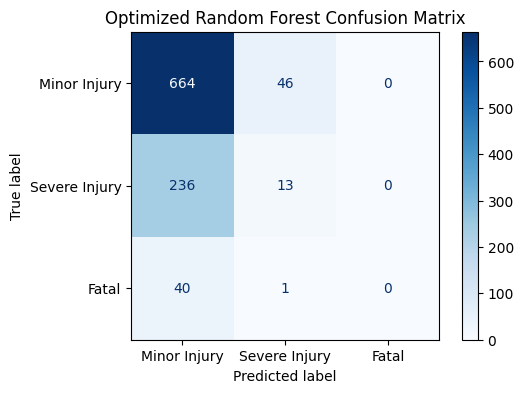

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Starting Grid Search for Random Forest...")

# ==========================================
# 1. Define the Parameter "Grid" to test
# ==========================================
param_grid_rf = {
    'criterion': ['gini', 'entropy'],             # How to measure the split quality
    'max_depth': [10, 15, 20],  # How deep the trees can grow
    'max_leaf_nodes': [50, 100, 200, 300]        # Max number of final branches
}

# ==========================================
# 2. Setup the Grid Search
# ==========================================
# We keep n_estimators=100 (standard) and class_weight='balanced' to protect minority classes
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# cv=5 (5-Fold Cross Validation). n_jobs=-1 (Use all CPU cores to run faster)
grid_search_rf = GridSearchCV(estimator=base_rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# ==========================================
# 3. Run the Iterations
# ==========================================
total_combos = len(param_grid_rf['criterion']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['max_leaf_nodes'])
print(f"Testing {total_combos} different combinations... (This might take a minute or two!)")

# We use the UNSCALED features for tree models
grid_search_rf.fit(X_train_final, y_encoded)

# ==========================================
# 4. Extract the Best Model
# ==========================================
print("\n✅ Random Forest Grid Search Complete!")
print(f"The absolute Best Parameters are: {grid_search_rf.best_params_}")

# Automatically grab the winning model
best_rf_model = grid_search_rf.best_estimator_

# ==========================================
# 5. Evaluate the Winning Model
# ==========================================
# Predict using the winning forest
train_preds_rf_best = best_rf_model.predict(X_train_final)
test_preds_rf_best = best_rf_model.predict(X_test_final)

print("\n--- Optimized Random Forest Results ---")
print(f"Training Accuracy: {accuracy_score(y_encoded, train_preds_rf_best):.4f}")
print(f"True Test Accuracy:  {accuracy_score(y_test_encoded, test_preds_rf_best):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, test_preds_rf_best, target_names=class_names))

# ==========================================
# 6. Plot Confusion Matrix for the Best Model
# ==========================================
cm_rf_best = confusion_matrix(y_test_encoded, test_preds_rf_best)
disp_rf_best = ConfusionMatrixDisplay(confusion_matrix=cm_rf_best, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp_rf_best.plot(cmap='Blues', ax=ax)
plt.title("Optimized Random Forest Confusion Matrix")
plt.show()

Starting Grid Search for Random Forest...
Testing 10 different combinations... (This might take a minute or two!)

✅ Random Forest Grid Search Complete!
The absolute Best Parameters are: {'criterion': 'entropy', 'max_depth': 20, 'max_leaf_nodes': 300}

--- Optimized Random Forest Results ---
Training Accuracy: 0.9940
True Test Accuracy:  0.6850

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.94      0.81       710
Severe Injury       0.27      0.06      0.10       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.69      1000
    macro avg       0.33      0.34      0.30      1000
 weighted avg       0.57      0.69      0.60      1000



c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


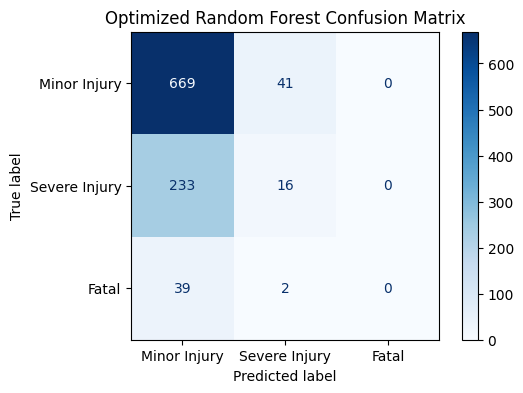

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Starting Grid Search for Random Forest...")

# ==========================================
# 1. Define the Parameter "Grid" to test
# ==========================================
param_grid_rf = {
    'criterion': ['gini', 'entropy'],             # How to measure the split quality
    'max_depth': [3,5,8,10,20],  # How deep the trees can grow
    'max_leaf_nodes': [300]
}

# ==========================================
# 2. Setup the Grid Search
# ==========================================
# We keep n_estimators=100 (standard) and class_weight='balanced' to protect minority classes
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# cv=5 (5-Fold Cross Validation). n_jobs=-1 (Use all CPU cores to run faster)
grid_search_rf = GridSearchCV(estimator=base_rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# ==========================================
# 3. Run the Iterations
# ==========================================
total_combos = len(param_grid_rf['criterion']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['max_leaf_nodes'])
print(f"Testing {total_combos} different combinations... (This might take a minute or two!)")

# We use the UNSCALED features for tree models
grid_search_rf.fit(X_train_final, y_encoded)

# ==========================================
# 4. Extract the Best Model
# ==========================================
print("\n✅ Random Forest Grid Search Complete!")
print(f"The absolute Best Parameters are: {grid_search_rf.best_params_}")

# Automatically grab the winning model
best_rf_model = grid_search_rf.best_estimator_

# ==========================================
# 5. Evaluate the Winning Model
# ==========================================
# Predict using the winning forest
train_preds_rf_best = best_rf_model.predict(X_train_final)
test_preds_rf_best = best_rf_model.predict(X_test_final)

print("\n--- Optimized Random Forest Results ---")
print(f"Training Accuracy: {accuracy_score(y_encoded, train_preds_rf_best):.4f}")
print(f"True Test Accuracy:  {accuracy_score(y_test_encoded, test_preds_rf_best):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_encoded, test_preds_rf_best, target_names=class_names))

# ==========================================
# 6. Plot Confusion Matrix for the Best Model
# ==========================================
cm_rf_best = confusion_matrix(y_test_encoded, test_preds_rf_best)
disp_rf_best = ConfusionMatrixDisplay(confusion_matrix=cm_rf_best, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 4))
disp_rf_best.plot(cmap='Blues', ax=ax)
plt.title("Optimized Random Forest Confusion Matrix")
plt.show()

Trying out parameters:

In [343]:
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Setting up Random Forest Iterations...")

# ==========================================
# 1. Create the Validation Set
# ==========================================
# Unscaled data is used for Random Forests
X_train, X_val, y_train, y_val = train_test_split(X_train_final, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# 2. Define the Parameter Space
# ==========================================
param_grid = {
    'class_weight': ['balanced', None],   # None represents standard 'imbalanced' weighting
    'criterion': ['gini'],
    'max_depth': [3, 5, 10, 20],
    'max_leaf_nodes': [5, 50, 100, None]
}

# ParameterGrid automatically creates a list of all 32 combinations
grid = ParameterGrid(param_grid)

print(f"Starting iteration over {len(grid)} combinations... This might take a minute!\n")
print("="*60)

# ==========================================
# 3. Loop Through and Evaluate Each Model
# ==========================================
for i, params in enumerate(grid, 1):
    print(f"\n--- Iteration {i}/{len(grid)} ---")
    print(f"Parameters: {params}")
    
    # Initialize the model with the current parameters (we unpack them using **)
    # Keeping n_estimators=100 as a standard baseline
    rf_model = RandomForestClassifier(**params, n_estimators=100, random_state=42)
    
    # Train on the 80% split
    rf_model.fit(X_train, y_train)
    
    # Predict on the validation split
    y_val_pred = rf_model.predict(X_val)
    
    # ==========================================
# 4. Print the Space-Saving Results
    # ==========================================
    print("\nConfusion Matrix (Row=True, Col=Predicted):")
    # Prints a clean, text-based matrix array to save screen space
    print(confusion_matrix(y_val, y_val_pred))
    
    print("\nClassification Report:")
    # zero_division=0 stops the red warning text if a model completely misses a class
    print(classification_report(y_val, y_val_pred, target_names=class_names, zero_division=0))
    print("="*60)

Setting up Random Forest Iterations...
Starting iteration over 32 combinations... This might take a minute!


--- Iteration 1/32 ---
Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': 5}

Confusion Matrix (Row=True, Col=Predicted):
[[206 216 126]
 [ 69  80  61]
 [ 17  12  13]]

Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      0.38      0.49       548
Severe Injury       0.26      0.38      0.31       210
        Fatal       0.07      0.31      0.11        42

     accuracy                           0.37       800
    macro avg       0.34      0.36      0.30       800
 weighted avg       0.55      0.37      0.42       800


--- Iteration 2/32 ---
Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': 50}

Confusion Matrix (Row=True, Col=Predicted):
[[234 199 115]
 [ 83  71  56]
 [ 14  15  13]]

Classification Report:
               precision  

Building Random Forest Classifier...
Random Forest training complete!

--- Random Forest Results ---
Training Accuracy: 0.4328
True Test Accuracy: 0.3530

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.72      0.36      0.48       710
Severe Injury       0.26      0.35      0.30       249
        Fatal       0.03      0.20      0.05        41

     accuracy                           0.35      1000
    macro avg       0.33      0.30      0.28      1000
 weighted avg       0.58      0.35      0.42      1000


Generating Confusion Matrix...


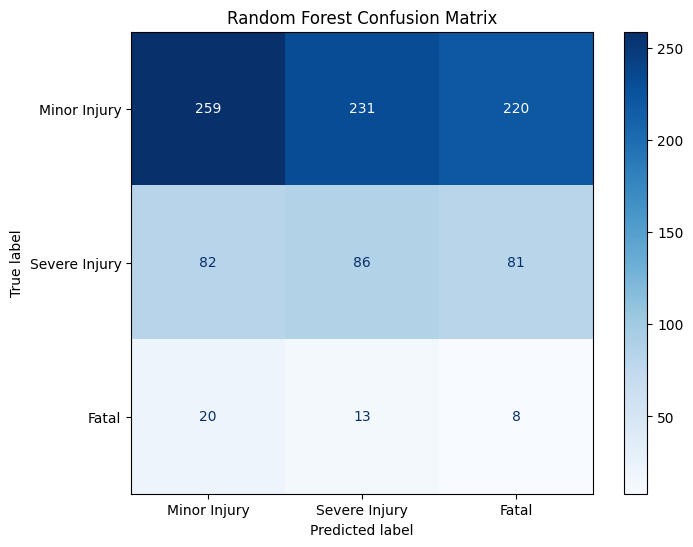


Calculating Feature Importances...


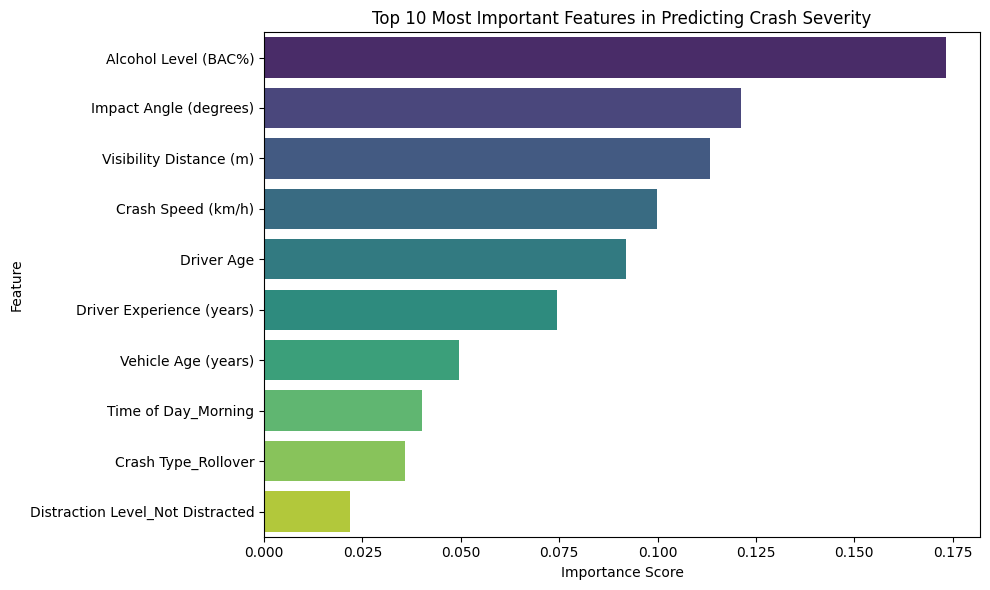

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Building Random Forest Classifier...")

# ==========================================
# 1. Initialize the Model
# ==========================================
# n_estimators=100 means the "Forest" will be made of 100 individual decision trees.
# max_depth=10 limits how deep each tree can go, preventing overfitting.
# class_weight='balanced' forces the forest to pay attention to Severe and Fatal crashes.
rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_depth=3, 
                                  class_weight='balanced', 
                                  random_state=42)

# ==========================================
# 2. Train the Model
# ==========================================
# IMPORTANT: We use the UNSCALED data (X_train_final)
rf_model.fit(X_train_final, y_encoded)

print("Random Forest training complete!")

# ==========================================
# 3. Predict on Test Data
# ==========================================
train_preds_rf = rf_model.predict(X_train_final)
test_preds_rf = rf_model.predict(X_test_final)

# ==========================================
# 4. Evaluate the Model
# ==========================================
print("\n--- Random Forest Results ---")
print(f"Training Accuracy: {accuracy_score(y_encoded, train_preds_rf):.4f}")
print(f"True Test Accuracy: {accuracy_score(y_test_encoded, test_preds_rf):.4f}")

print("\nDetailed Classification Report:")
# Using your class_names list ('Minor', 'Severe', 'Fatal')
print(classification_report(y_test_encoded, test_preds_rf, target_names=class_names))

# ==========================================
# 5. Compute and Plot Confusion Matrix
# ==========================================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, test_preds_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================
# 6. Bonus: Plot Feature Importances
# ==========================================
print("\nCalculating Feature Importances...")
# Random Forests automatically rank which columns were the most helpful in predicting crashes!
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

# Create a DataFrame to sort the top 10 most important features
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Most Important Features in Predicting Crash Severity")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Logistic regression:**

Notes:

-Takes scaled data

-Handles correlated data

-class_weight='balanced' parameter improves the importance of the rare data (fatal)

Building Multi-Class Logistic Regression Model...
Logistic Regression model training complete!

--- Logistic Regression Results ---
Training Accuracy: 0.34125
True Test Accuracy: 0.316

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.72      0.30      0.43       710
Severe Injury       0.26      0.33      0.29       249
        Fatal       0.04      0.41      0.08        41

     accuracy                           0.32      1000
    macro avg       0.34      0.35      0.27      1000
 weighted avg       0.58      0.32      0.38      1000


Generating Confusion Matrix...


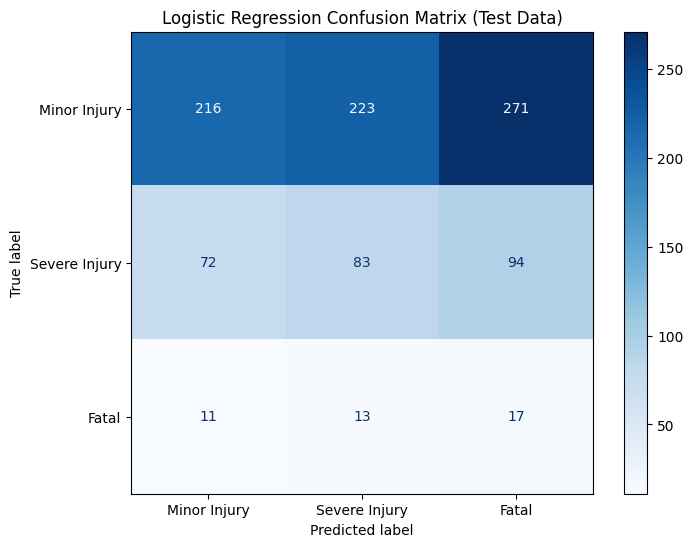

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Building Multi-Class Logistic Regression Model...")

# ==========================================
# 1. Initialize the Model
# ==========================================

# class_weight='balanced' is the magic fix for your "Minor Injury" bias!
#log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced')
log_model = LogisticRegression(class_weight='balanced')

# ==========================================
# 2. Train the Model
# ==========================================
# IMPORTANT: We use the SCALED data here, as Logistic Regression requires it!
log_model.fit(X_train_scaled, y_encoded)

print("Logistic Regression model training complete!")

# ==========================================
# 3. Predict on Test Data
# ==========================================
train_preds = log_model.predict(X_train_scaled)
test_preds = log_model.predict(X_test_scaled)

# ==========================================
# 4. Evaluate the Model
# ==========================================
print("\n--- Logistic Regression Results ---")
print("Training Accuracy:", accuracy_score(y_encoded, train_preds))
print("True Test Accuracy:", accuracy_score(y_test_encoded, test_preds))

print("\nDetailed Classification Report:")
# Using the class_names list from your preprocessing ('Minor', 'Severe', 'Fatal')
print(classification_report(y_test_encoded, test_preds, target_names=class_names))

# ==========================================
# 5. Compute and Plot Confusion Matrix
# ==========================================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, test_preds)

# Display the matrix using your exact class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Logistic Regression Confusion Matrix (Test Data)")
plt.show()

**Naive Bayes:**

Notes:
-Doesn't need scalin, since the features are mostly categorical and since the naive bayes is based on probability

-Must make sure the features are uncorrelated such as (rain) and (wet road) for example: keeping both would cause Naive Bayes to punish (or reward) a probability twice for the exact same physical event.

-Approach A: pass the an unscaled one-hot encoded df into GaussianNB
    GaussianNB assumes every feature is normally distributed. Yet, it is robust to mixed data

-Approach B: Use GaussianNB for continous data and BernoulliNB for binary. ie; library like mixed-naive-bayes

Approch A:

In [244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. Capture the Unscaled Data for Naive Bayes
# ==========================================
# Use the final dataframes right before you applied StandardScaler
X_train_nb = X_train_final.copy()
X_test_nb = X_test_final.copy()

# ==========================================
# 2. Check for Redundant Categorical Features
# ==========================================
corr_matrix = X_train_nb.corr()



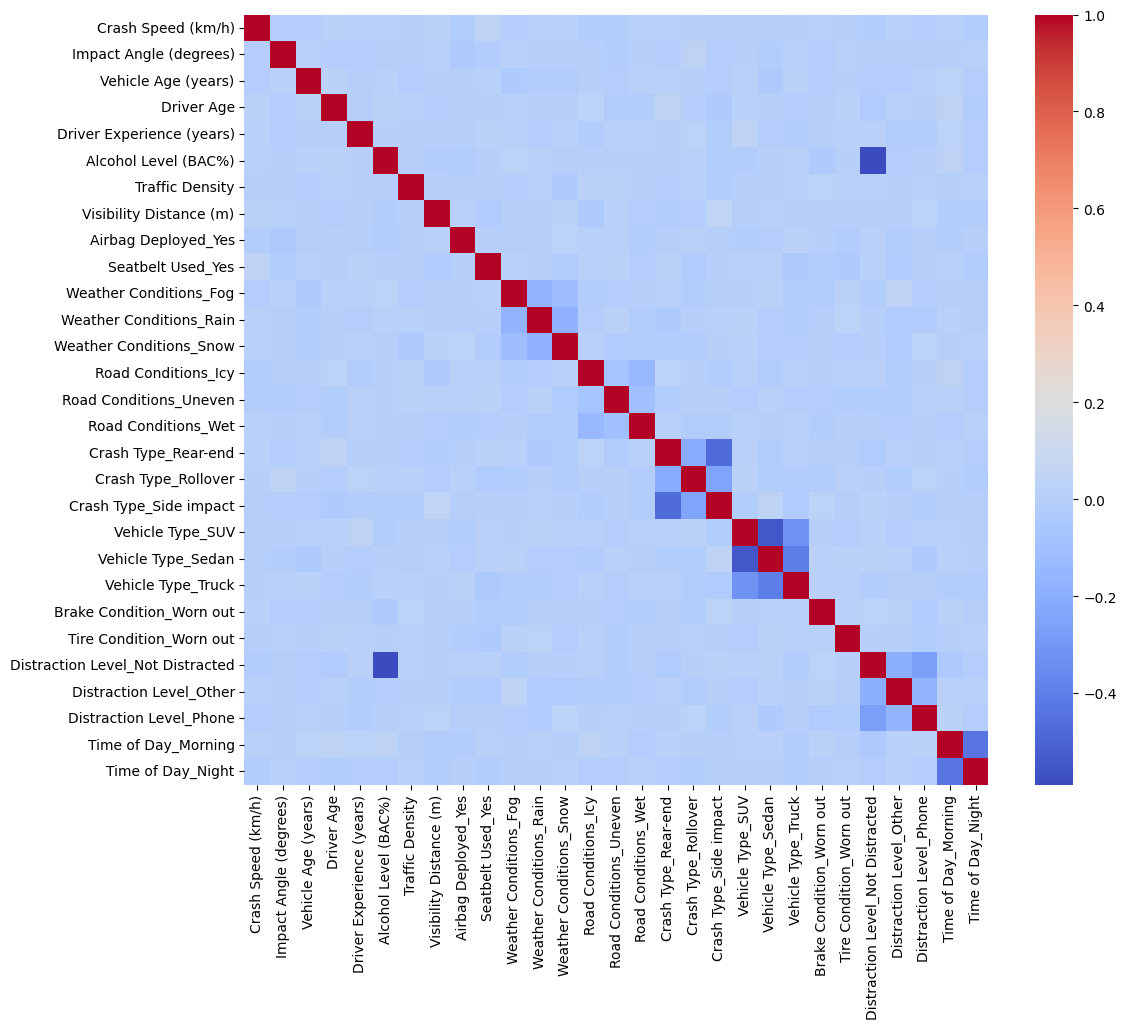

In [245]:
# Optional: Visualize it to see if any one-hot columns are highly correlated
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()



In [246]:
# Automatically find and drop one of the features if correlation is > 0.80 or < -0.80
columns_to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.80:
            colname = corr_matrix.columns[i]
            columns_to_drop.add(colname)

if columns_to_drop:
    print(f"Dropping highly correlated columns for Naive Bayes: {columns_to_drop}")
    X_train_nb = X_train_nb.drop(columns=columns_to_drop)
    X_test_nb = X_test_nb.drop(columns=columns_to_drop)

# ==========================================
# 3. Train and Predict with GaussianNB
# ==========================================
# Initialize the model
nb_model = GaussianNB()

# Fit using the UNSCALED, independent features against the training labels
nb_model.fit(X_train_nb, y_encoded)

print("\nNaive Bayes model training complete!")

# ==========================================
# 4. Evaluate the Model
# ==========================================
# Check Training Accuracy
train_preds = nb_model.predict(X_train_nb)
print("Training Accuracy:", accuracy_score(y_encoded, train_preds))

# Check True Test Accuracy!
test_preds = nb_model.predict(X_test_nb)
print("True Test Accuracy:", accuracy_score(y_test_encoded, test_preds))

# Print a detailed report
print("\nDetailed Classification Report:")
# CHANGED: Replaced le.classes_ with class_names
print(classification_report(y_test_encoded, test_preds, target_names=class_names))




Naive Bayes model training complete!
Training Accuracy: 0.6685
True Test Accuracy: 0.7

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.72      0.96      0.82       710
Severe Injury       0.39      0.08      0.13       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.70      1000
    macro avg       0.37      0.35      0.32      1000
 weighted avg       0.61      0.70      0.61      1000




Generating Confusion Matrix...


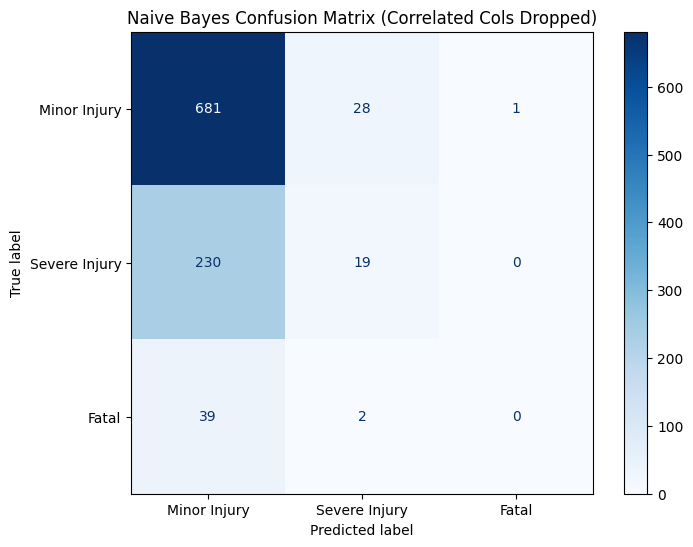

In [ ]:
# ==========================================
# 5. Compute and Plot Confusion Matrix
# ==========================================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Naive Bayes Confusion Matrix (Correlated Cols Dropped)")
plt.show()

Approach B:

Building Mixed Naive Bayes Model...
-> Found 8 numeric columns for GaussianNB.
-> Found 21 binary/categorical columns for BernoulliNB.

--- Mixed Naive Bayes Results ---
True Test Accuracy: 0.71

Detailed Classification Report:
               precision    recall  f1-score   support

 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249
        Fatal       0.00      0.00      0.00        41

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000


Generating Confusion Matrix...


c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


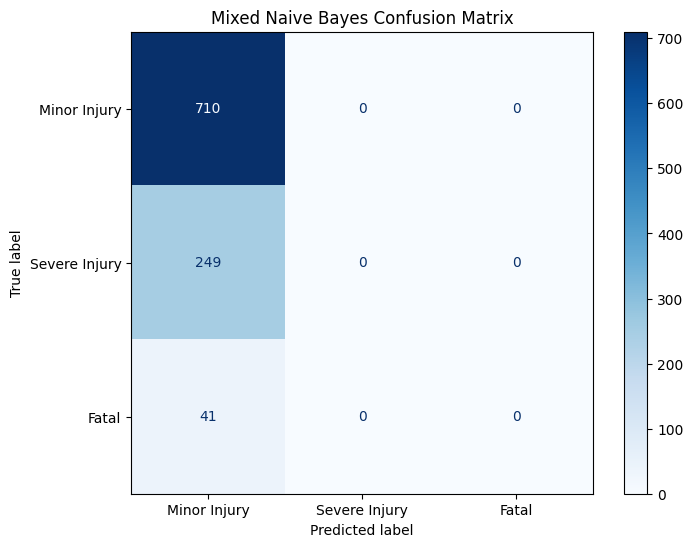

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Building Mixed Naive Bayes Model...")

# ==========================================
# 1. Split Features into Numeric and Binary
# ==========================================
# We can do this automatically! If a column only has 2 unique values (0 and 1), 
# it belongs to Bernoulli. If it has more (like Speed, Age, or Traffic Density 1-2-3), 
# it belongs to Gaussian.

binary_cols = [col for col in X_train_final.columns if X_train_final[col].nunique() <= 2]
numeric_cols = [col for col in X_train_final.columns if col not in binary_cols]

print(f"-> Found {len(numeric_cols)} numeric columns for GaussianNB.")
print(f"-> Found {len(binary_cols)} binary/categorical columns for BernoulliNB.")

X_train_num = X_train_final[numeric_cols]
X_test_num  = X_test_final[numeric_cols]

X_train_bin = X_train_final[binary_cols]
X_test_bin  = X_test_final[binary_cols]

# ==========================================
# 2. Train Both Models Separately
# ==========================================
gnb = GaussianNB()
bnb = BernoulliNB()

# Using y_encoded (from our Ordinal Mapping)
gnb.fit(X_train_num, y_encoded)
bnb.fit(X_train_bin, y_encoded)

# ==========================================
# 3. Get Predicted Probabilities
# ==========================================
# Instead of getting hard guesses, we ask both models for their confidence 
# percentages (probabilities) for Minor, Severe, and Fatal.
prob_gnb_test = gnb.predict_proba(X_test_num)
prob_bnb_test = bnb.predict_proba(X_test_bin)

# ==========================================
# 4. Average the Probabilities (The "Mix")
# ==========================================
# We add their confidence scores together and divide by 2
avg_prob_test = (prob_gnb_test + prob_bnb_test) / 2.0

# Choose the class with the highest combined probability
final_test_preds = np.argmax(avg_prob_test, axis=1)

# ==========================================
# 5. Evaluate the Mixed Model
# ==========================================
print("\n--- Mixed Naive Bayes Results ---")
print("True Test Accuracy:", accuracy_score(y_test_encoded, final_test_preds))

print("\nDetailed Classification Report:")
# CHANGED: Replaced le.classes_ with class_names
print(classification_report(y_test_encoded, final_test_preds, target_names=class_names))

# Generate the Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_encoded, final_test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Mixed Naive Bayes Confusion Matrix")
plt.show()

Trying out Gaussian but without removing correlated data:


Note: produced same exact result

Conclusion: Experimenting with Naive Bayes on Car Crash Data
While Naive Bayes is a fast and efficient baseline model, it proved to be an underperformer for this specific dataset. The experiment demonstrated that the mathematical assumptions required by Naive Bayes do not align well with the complex, interdependent nature of car accident physics.